## Resources

In [43]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('heart.csv')

display(df.head())

print("\nDataFrame Information:")
display(df.info())

print("\nDescriptive Statistics:")
display(df.describe())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None


Descriptive Statistics:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Data Cleaning and Preprocessing - Initial Overview

In [44]:
print("\nMissing values per column:")
display(df.isnull().sum())

# Check for duplicate rows in the DataFrame
print("\nNumber of duplicate rows:")
display(df.duplicated().sum())



Missing values per column:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Number of duplicate rows:


0

### Exploring Categorical Features

Let's inspect the unique values and their counts for all 'object' type (categorical) columns to understand their distribution and identify any inconsistencies.

In [45]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    display(df[col].value_counts())



Unique values in 'Sex':


Sex
M    725
F    193
Name: count, dtype: int64


Unique values in 'ChestPainType':


ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


Unique values in 'RestingECG':


RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


Unique values in 'ExerciseAngina':


ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


Unique values in 'ST_Slope':


ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

## Data Preprocessing - One-Hot Encoding

To prepare the categorical features for machine learning models, we will apply one-hot encoding. This process converts each category into a new binary column.

In [46]:
from numpy import dtype
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True).astype(int)


print("\nFirst 5 rows of the one-hot encoded DataFrame:")
display(df_encoded.head())

print("\nInformation of the one-hot encoded DataFrame:")
display(df_encoded.info())



First 5 rows of the one-hot encoded DataFrame:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1



Information of the one-hot encoded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                918 non-null    int64
 1   RestingBP          918 non-null    int64
 2   Cholesterol        918 non-null    int64
 3   FastingBS          918 non-null    int64
 4   MaxHR              918 non-null    int64
 5   Oldpeak            918 non-null    int64
 6   HeartDisease       918 non-null    int64
 7   Sex_M              918 non-null    int64
 8   ChestPainType_ATA  918 non-null    int64
 9   ChestPainType_NAP  918 non-null    int64
 10  ChestPainType_TA   918 non-null    int64
 11  RestingECG_Normal  918 non-null    int64
 12  RestingECG_ST      918 non-null    int64
 13  ExerciseAngina_Y   918 non-null    int64
 14  ST_Slope_Flat      918 non-null    int64
 15  ST_Slope_Up        918 non-null    int64
dtypes: int64(16)
me

None

## Exploratory Data Analysis (EDA)

Now that the data is cleaned and preprocessed, let's move on to Exploratory Data Analysis (EDA) to gain insights into the dataset and its distributions. We will start by examining the distribution of the target variable `HeartDisease`.

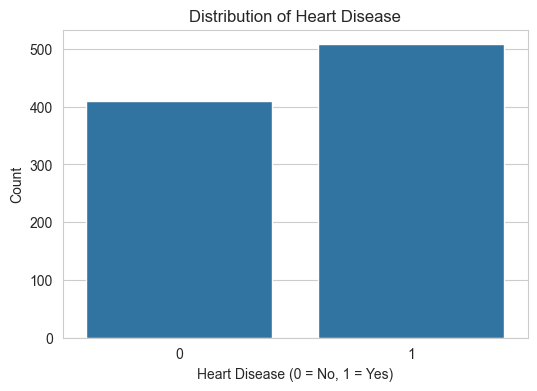


Distribution of HeartDisease:


HeartDisease
1    508
0    410
Name: count, dtype: int64


Percentage of HeartDisease:


HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df_encoded)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print("\nDistribution of HeartDisease:")
display(df_encoded['HeartDisease'].value_counts())
print("\nPercentage of HeartDisease:")
display(df_encoded['HeartDisease'].value_counts(normalize=True) * 100)


### Correlation Matrix

Let's visualize the correlation matrix to understand the linear relationships between all numerical features, including the one-hot encoded categorical variables and the target variable (`HeartDisease`). This will highlight potential strong positive or negative correlations.

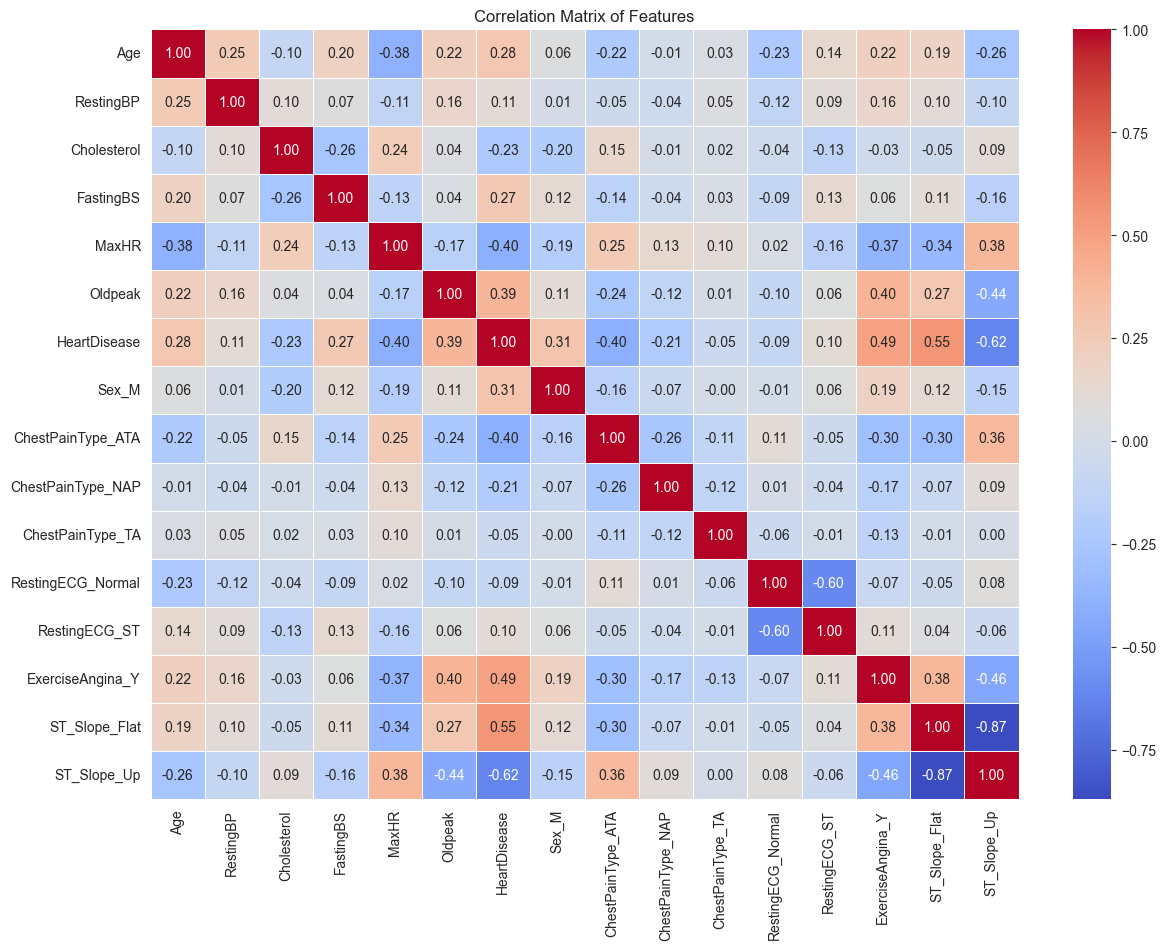


Correlations with HeartDisease:


HeartDisease         1.000000
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.392385
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
RestingBP            0.107589
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

In [48]:
corr_matrix = df_encoded.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

# Display correlations with the target variable 'HeartDisease'
print("\nCorrelations with HeartDisease:")
display(corr_matrix['HeartDisease'].sort_values(ascending=False))


### Numerical Feature Distributions

Next, let's visualize the distributions of key numerical features, separated by the `HeartDisease` outcome, using histograms and kernel density plots. This can reveal differences in feature values between healthy individuals and those with heart disease.

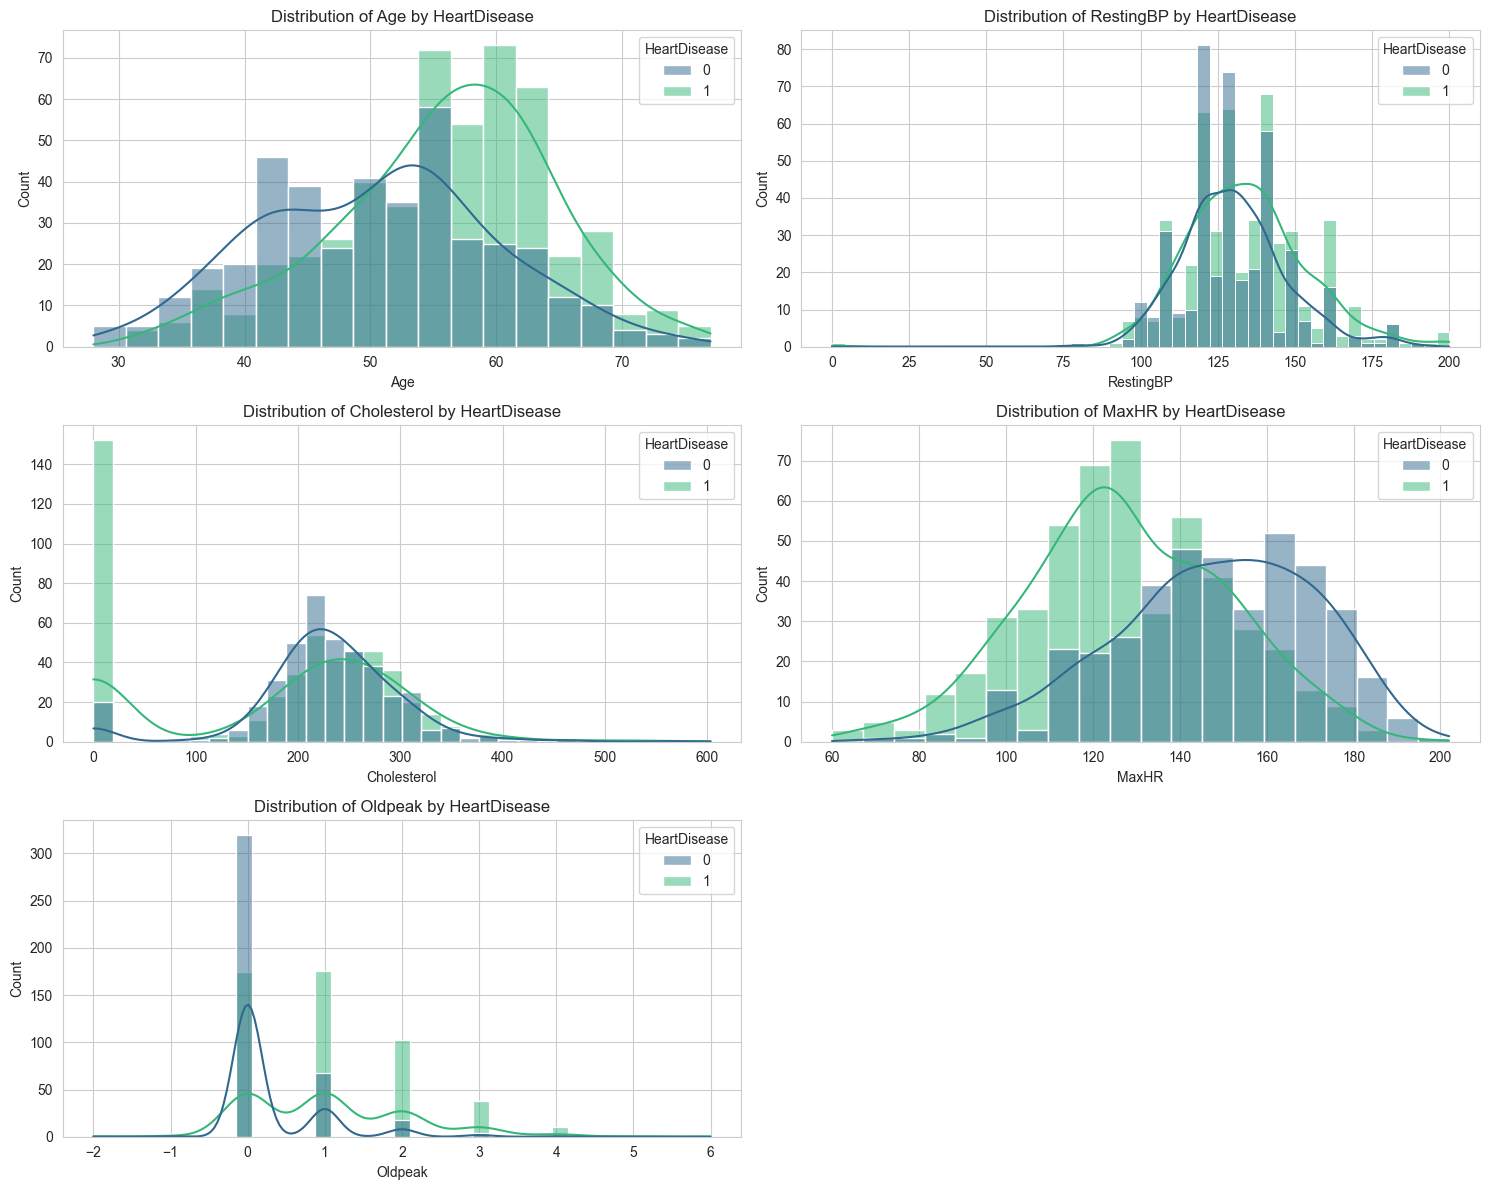

In [49]:
numerical_cols_for_eda = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols_for_eda):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 3x2 grid
    sns.histplot(data=df_encoded, x=col, hue='HeartDisease', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by HeartDisease')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Categorical Feature Relationships with HeartDisease

Let's visualize how the one-hot encoded categorical features relate to the presence of heart disease. We will use bar plots to show the proportion of HeartDisease for each category.

In [50]:
one_hot_cols = df_encoded.select_dtypes(include='bool').columns.tolist()

if 'HeartDisease' in one_hot_cols:
    one_hot_cols.remove('HeartDisease')

plt.figure(figsize=(18, 15))
for i, col in enumerate(one_hot_cols):
    plt.subplot(4, 3, i + 1) # Adjust grid size as needed
    sns.barplot(x=col, y='HeartDisease', data=df_encoded, palette='viridis')
    plt.title(f'HeartDisease Proportion by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion of HeartDisease')
plt.tight_layout()
plt.show()


<Figure size 1800x1500 with 0 Axes>

## Data Preparation for Model Training

Now that we have cleaned, preprocessed, and explored the data, the next step is to prepare it for machine learning model training. This typically involves:

1.  **Splitting the data**: Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data.
2.  **Feature Scaling**: Scaling numerical features to a standard range to prevent features with larger values from dominating the learning process.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (734, 15)
Shape of X_test: (184, 15)
Shape of y_train: (734,)
Shape of y_test: (184,)


### Feature Scaling

We will apply `StandardScaler` to the numerical features in our dataset. This scaler transforms data such that its distribution has a mean of 0 and a standard deviation of 1. It's crucial to fit the scaler only on the training data to avoid data leakage and then transform both training and testing sets.

In [52]:
numerical_cols_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()

X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("\nFirst 5 rows of X_train after scaling numerical features:")
display(X_train.head())

print("\nFirst 5 rows of X_test after scaling numerical features:")
display(X_test.head())



First 5 rows of X_train after scaling numerical features:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,0.127137,1,-0.324520,0.307362,1,1,0,0,0,1,1,1,0
486,0.122028,-1.266031,0.099443,1,1.689837,-0.722792,1,1,0,0,0,1,0,0,1
117,0.546020,-0.159102,1.244113,1,-0.247045,0.307362,0,0,0,0,0,1,1,1,0
361,-0.725956,1.501291,-1.876035,0,-0.479470,-0.722792,1,0,0,0,1,0,1,1,0
296,-0.407962,0.671094,-1.876035,1,0.101594,-0.722792,1,0,0,0,1,0,1,1,0



First 5 rows of X_test after scaling numerical features:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
356,-0.831954,-0.989299,-1.876035,0,-0.905584,0.307362,1,0,0,0,1,0,1,1,0
763,0.440022,-0.048409,0.191755,0,1.418673,2.367671,1,0,1,0,0,0,0,0,1
817,0.652018,-0.435834,0.505616,0,0.179069,1.337517,1,0,0,0,0,0,1,1,0
735,-0.513960,-0.712567,-0.140568,0,0.101594,1.337517,1,0,1,0,1,0,0,1,0
892,-1.573940,0.283669,0.154830,0,0.605183,-0.722792,0,0,1,0,1,0,0,1,0


## Model Training and Evaluation

With the data prepared, we can now proceed to train a machine learning model. We will start with a Logistic Regression model as a baseline for classification, then evaluate its performance using various metrics.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42, kernel='rbf')
}

all_model_metrics = {}

for model_name, model_instance in models.items():
    model_instance.fit(X_train, y_train)
    y_pred_current = model_instance.predict(X_test)
    y_pred_proba_current = model_instance.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_current)
    precision = precision_score(y_test, y_pred_current)
    recall = recall_score(y_test, y_pred_current)
    f1 = f1_score(y_test, y_pred_current)
    roc_auc = roc_auc_score(y_test, y_pred_proba_current)

    all_model_metrics[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }



In [54]:
# Create a DataFrame for comparison from the collected metrics
metrics_df = pd.DataFrame(all_model_metrics).T # Transpose to have models as rows
metrics_df = metrics_df.round(4) # Round to 4 decimal places for readability

print("\n--- Model Performance Comparison ---")
display(metrics_df.sort_values(by='Accuracy', ascending=False))


--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Naive Bayes,0.9130,0.9300,0.9118,0.9208,0.9455
SVM,0.8967,0.8807,0.9412,0.9100,0.9436
Logistic Regression,0.8859,0.8716,0.9314,0.9005,0.9317
KNN,0.8750,0.8624,0.9216,0.8910,0.9211
Decision Tree,0.7772,0.7798,0.8333,0.8057,0.7703


In [55]:
import joblib as jb

jb.dump(models['Naive Bayes'], 'NV-model.pkl')
jb.dump(scaler, 'scaler.pkl')
jb.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']